In [1]:
import xarray as xr
import numpy as np
import jax.numpy as jnp

from scipy.signal.windows import tukey

import sys
sys.path.append('../subroutine')
from rfft2 import rfft2, irfft2
from rel_err import rel_err
from isospec_rfft import isospec_rfft

import matplotlib.pyplot as plt
import matplotlib.colors as colors
from mpl_toolkits.axes_grid1 import ImageGrid
import cmocean.cm as cmo
plt.style.use('/mnt/c/Ryan_Data/Python_Tool/ryan_mplstyle.mplstyle')

#####################################
import jax.numpy as jnp
import jaxopt

#####################################
# from scipy.stats import wasserstein_distance, wasserstein_distance_nd

OSError: '/mnt/c/Ryan_Data/Python_Tool/ryan_mplstyle.mplstyle' is not a valid package style, path of style file, URL of style file, or library style name (library styles are listed in `style.available`)

This cell import the data for analysis. 

In [14]:
ds_truth = xr.open_dataset("data/data_channel/processed/truth.nc")
ds_lpfilter = xr.open_dataset("data/data_channel/processed/Fourier_lpfilter.nc")
ds_GeoBal = xr.open_dataset("data/data_channel/processed/Geo_Balanced.nc")

Extract x and y values (suppose to be surface data so it is $2D$. )

In [15]:
x = ds_truth.x.values
y = ds_truth.y.values

xl = ds_lpfilter.cut_id.values; xh = -ds_lpfilter.cut_id.values
yl = ds_lpfilter.cut_id.values; yh = -ds_lpfilter.cut_id.values

Question : What does these two press and lowpass pression means?

In [16]:
press_lpfilter = ds_lpfilter.press_lpfilter.values
lowpass_filter = ds_lpfilter.lowpass_filter.values

Non dimensionalization

In [ ]:
# Some decision to nondim, maybe play around here
f = ds_truth.f.values

Ro = 1
Ld = 8*1e3
# Ld = 1
Ud = Ro*Ld*f

Grid Setup

In [ ]:
dui = 1e3 # dx of raw data in meter

XC_Ld = ds_truth.x.values/Ld
YC_Ld = ds_truth.y.values/Ld
kx_Ld = np.fft.rfftfreq(press_lpfilter.shape[1],d=dui/Ld)*(2*np.pi)
ky_Ld =  np.fft.fftfreq(press_lpfilter.shape[0],d=dui/Ld)*(2*np.pi)

print(kx_Ld[1])

0.12566370614359174


Normalize the pressure field

In [ ]:
press_lpndim = press_lpfilter/(f*Ud*Ld) # it is the unit of pressure, I think

print(np.std(press_lpndim))
print(np.std(press_lpndim)*kx_Ld[1]**2*Ro)

2.155169
0.03403306487646362


Logic: Pre-computes isotropic wavenumber operators required for spectral derivatives.K2: Squared wavenumber ($k^2 + l^2$), corresponds to Laplacian $-\nabla^2$.Ka: Wavenumber magnitude $\sqrt{k^2 + l^2}$, corresponds to the vertical derivative operator $\partial_z$ in SQG theory (related to the Hilbert transform).Kn2: Inverse Laplacian operator ($1/K^2$) for inverting vorticity.

In [ ]:
kx = kx_Ld; ky = ky_Ld
kx_mat, ky_mat = jnp.meshgrid(kx, ky)
K2 = (kx_mat**2+ky_mat**2)
Ka = jnp.sqrt(K2)
Kaa = Ka.at[0,0].set(1e-13)
# Kaa = Ka

# Inverted K, set non infinity value at (0,0). 
Kn2 = 1/(K2.at[0,0].set(1e16))

###
press_lpndim__ = rfft2(press_lpndim)

This function defines the Geostrophic Vorticity, the definition is $$\zeta_{QG} = \nabla^2 \psi$$

In this ceel what is actually defined is the fourier transform of $\zeta$. $$\hat{\zeta}_{QG} = -(k_x^2 + k_y^2) \hat{\psi}$$ 

In [21]:
def ZETA_QG__(phi0s__):
    phi0s_xx__ = (phi0s__*-1*kx_Ld**2)
    phi0s_yy__ = ((phi0s__.T*-1*ky_Ld**2).T)

    zeta_f_SI = (phi0s_xx__+phi0s_yy__)
    return zeta_f_SI

Formula: This term represents the ageostrophic divergence forcing in the Nonlinear Balance Equation (NBE):
$$\text{Cyclo} = 2 \left( \frac{\partial^2 \psi}{\partial x^2} \frac{\partial^2 \psi}{\partial y^2} - \left(\frac{\partial^2 \psi}{\partial x \partial y}\right)^2 \right)$$

This is the RHS of the equation 
$$     \boxed{\nabla^2 p^1 - f\xi^1 = 2J(\Phi_x^0, \Phi_y^0)}$$

$\psi$ in this code is $\Phi_x^0$ in the note. 

In [ ]:
def CYCLO_TERM__(phi0s__):
    
    phi0s_xx = irfft2(phi0s__*-1*kx**2)
    phi0s_yy = irfft2((phi0s__.T*-1*ky**2).T)
    phi0s_xy = irfft2(phi0s__*-1*jnp.outer(ky,kx))

    return -rfft2(2*(phi0s_xx*phi0s_yy-phi0s_xy**2))*Kn2 # this is for pressure

Multiplication is hard in spectral space, so we first go back to physical space using irfft2 then do the multiplication and go back to spectral space using rfft2. Since $q^1$ is 0, then from my note we have 
$$     \mathcal{L}(\Phi^1) = \frac{1}{\text{Bu}} \left( |\nabla\Phi_z^0|^2 - \Phi_{zz}^0 \nabla^2 \Phi^0 \right)$$

Term_1 below is 
$$ (\Phi^0_{xz})^2 + (\Phi^0_{yz})^2 = |\nabla \Phi^0_z|^2$$

Term 2 below is 
$$ 2 \times (\Phi^0_z \cdot \Delta \Phi^0_z)$$

Term 3 is 
$$ \Phi^0_{zz} \cdot \nabla^2 \Phi^0 $$

Term 4 is 
$$ \Phi^0_x \cdot \Phi^0_{zzx} + \Phi^0_y \cdot \Phi^0_{zzy} $$

Term 5: Vertical derivative of the product of the first and second vertical derivatives. $$ \text{Term}5 = |\mathbf{k}| \mathcal{F}\left[ \psi_z \psi{zz} \right] = \mathcal{F}\left[ \partial_z (\psi_z \psi_{zz}) \right] $$

Term 6 & Term 7: Represent the vertical derivative of the divergence of the flux of vertical momentum. $$ \text{Term}6 = - \mathcal{F}\left[ \partial_{yz} (\psi_z \psi_y) \right] $$ $$ \text{Term}7 = - \mathcal{F}\left[ \partial_{xz} (\psi_z \psi_x) \right] $$

The returned function is 
$$ \text{Return} = \left( \sum_{i=1}^7 \text{Term}_i \right) \times \text{LowpassFilter} $$

Physically, the sum (before filtering) corresponds to: $$ \mathcal{F} \left[ 2|\nabla_H \psi_z|^2 + 2\psi_z \nabla^2 \psi_z + \psi_{zz} \nabla^2 \psi + \nabla_H \psi \cdot \nabla_H \psi_{zz} + \partial_z(\psi_z \psi_{zz}) - \partial_z \nabla_H \cdot (\psi_z \nabla_H \psi) \right] $$

So this part is basically the 
$$f\zeta^1$$
part. Stil trying to figure out.




In [ ]:
# Many different version, I have checked they all spit out the same thing!
def ZETAp1__(phi0s__):
    phi0s_xz = irfft2(phi0s__*1j*kx*Ka)
    phi0s_yz = irfft2((phi0s__.T*1j*ky*Ka.T).T)
    term_1 = rfft2(2*(phi0s_xz**2+phi0s_yz**2))

    phi0s_z = irfft2(phi0s__*Ka)
    phi0s_lapz = irfft2(-phi0s__*Ka*K2)
    term_2 = rfft2(2*(phi0s_z*phi0s_lapz))

    phi0s_zz = irfft2(phi0s__*Ka*Ka)
    phi0s_lap = irfft2(-phi0s__*K2)
    term_3 = rfft2((phi0s_zz*phi0s_lap))

    phi0s_x = irfft2(phi0s__*1j*kx)
    phi0s_y = irfft2((phi0s__.T*1j*ky).T)
    phi0s_zzx = irfft2(phi0s__*Ka*Ka*1j*kx)
    phi0s_zzy = irfft2((phi0s__.T*Ka.T*Ka.T*1j*ky).T)
    term_4 = rfft2((phi0s_x*phi0s_zzx+phi0s_y*phi0s_zzy))

    term_5 = rfft2(phi0s_z*phi0s_zz)*Ka
    term_6 = -(rfft2(phi0s_z*phi0s_y).T*1j*ky*Ka.T).T
    term_7 = -rfft2(phi0s_z*phi0s_x)*1j*kx*Ka

    return ( (term_1+term_2+term_3+term_4)*1 \
          +(term_5)*1 \
          +(term_6+term_7)*1 )*lowpass_filter # Achtung, some LPF here

In [ ]:
def ZP1_TERM__(phi0s__):
    return - ZETAp1__(phi0s__)*Kn2 # this is for pressure 

In [79]:
# plt.pcolor(irfft2(ZETAp1__(params_lp__))[xl:xh,yl:yh], cmap=cmo.balance, vmin=-2, vmax=2)
# plt.colorbar()

# print(np.std(irfft2(ZETAp1__(params_lp__))))

In [80]:
# plt.pcolor(irfft2(CYCLO_TERM__(params_lp__)*(-K2))[xl:xh,yl:yh], cmap=cmo.balance, vmin=-2, vmax=2)
# plt.colorbar()

# print(np.std(irfft2(ZETAp1__(params_lp__))))

Set the expansion parameter $\epsilon$. 

In [ ]:
# Achtung
eps = Ro*0.25

Here define the lost function for the JAX optimizer. 
$$\text{Minimize} \quad || P_{obs} - (\psi^0 + \epsilon \cdot [\text{Cyclo}(\psi^0) + \text{ZP1}(\psi^0)]) ||^2$$

In [ ]:
# This is the JAX
# params__ is phi0s__ if solved correctly

def err(params__):
    # corr is pressure correction at +1 order
    cyclo_corr = CYCLO_TERM__(params__)
    zp1_corr = ZP1_TERM__(params__)

    err_spec = 1+(Kaa**(2)) # aritficial white the spectrum, can play with the shape
    # err_spec = 1
    
    # This is the L2 error with whitening 
    return jnp.sum(  jnp.abs(press_lpndim__-params__-eps*(cyclo_corr+zp1_corr))**2      *err_spec )
    # eta_lowpass_simulation - eta^0 - eps*eta^1

use the L-BFGS algorithm to solve the optimiation problem as in the cell above. 

In [ ]:
solver = jaxopt.LBFGS(fun=err, maxiter=300, tol=1e-3)
# Alternatively, can just fix-point iteration, like cyclo (not JAXparrow)
# Worry: prob not gonna converge, maybe just stop after a few iterations
# Can play with optimizer, like SGD, adam, in other version
# Error stop decreasing after a while...
# Might explode with large eps

In [84]:
res = solver.run(press_lpndim__)
# res = solver.run(params__)

In [85]:
params__, state = res;
print(state[0])
print(err(press_lpndim__))
print(state[1])
print(state[1]/err(press_lpndim__))

300
0.04051776
0.00016562197
0.004087639


Logic: Reconstructs the total balanced pressure field using the optimized $\psi^0$ and the calculated corrections.$$P_{total} = \psi^0_{opt} + \epsilon (\text{Cyclo}_{opt} + \text{ZP1}_{opt})$$

In [86]:
totp1pres__ = params__+eps*(CYCLO_TERM__(params__)+ZP1_TERM__(params__))
totp1pres = irfft2( totp1pres__ )

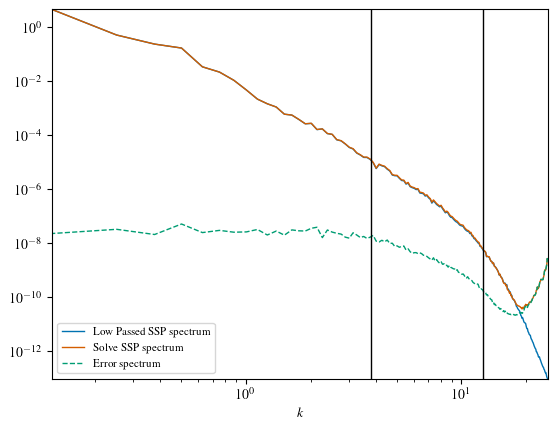

In [87]:
press_spec = isospec_rfft( np.abs(press_lpndim__)**2 )
params_spec = isospec_rfft( np.abs(params__)**2 )
totp1pres_spec = isospec_rfft( np.abs(totp1pres__)**2 )
err_spec = isospec_rfft( np.abs(press_lpndim__-totp1pres__)**2 )

k_ndim = np.arange(0,press_spec.size,1.)*(kx_Ld[1])
k_fac = kx_Ld[1]/(1/1e3)
plt.loglog(k_ndim,press_spec,label="Low Passed SSP spectrum")
plt.loglog(k_ndim,totp1pres_spec,label="Solve SSP spectrum")
plt.loglog(k_ndim,err_spec,'--',label="Error spectrum")

# plt.loglog(k_ndim,k_ndim**(-const_slope)/const_eta/Ro**2,'k')

# plt.axvline(1/15*k_fac,color='k')
# plt.axvline(1/38*k_fac,color='k')
plt.axvline(1/33*k_fac,color='k')
plt.axvline(1/10*k_fac,color='k')

# plt.ylim([1e-16,1e3])
plt.xlabel("$k$ ")
plt.legend()

In [ ]:
zeta_SQGp1__ = Ro*(ZETA_QG__(params__)+eps*ZETAp1__(params__))
zeta_SQGp1__ = zeta_SQGp1__*lowpass_filter**1 # Filtered here

zeta_Truth__ = rfft2(ds_lpfilter.zeta_windowed.values)*lowpass_filter**0 # But not here
zeta_Truth = irfft2(zeta_Truth__)

0.4126904
0.4944511
0.16535652


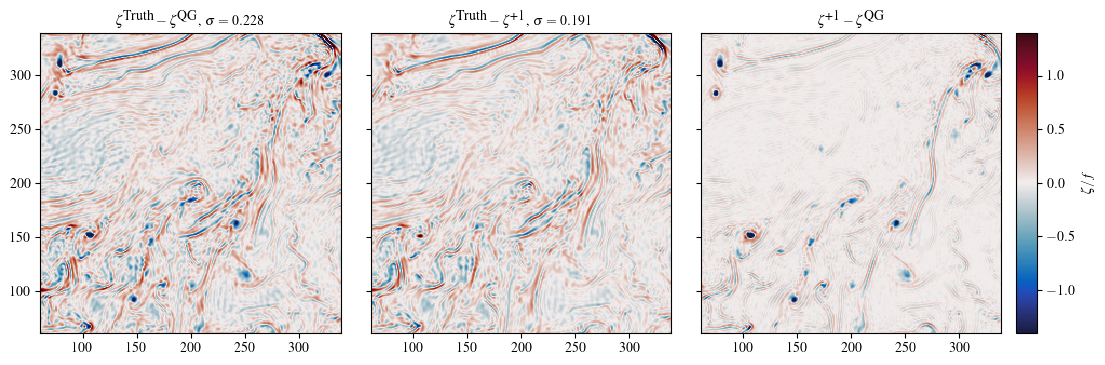

In [93]:
xl = ds_lpfilter.cut_id.values; xh = -ds_lpfilter.cut_id.values
yl = ds_lpfilter.cut_id.values; yh = -ds_lpfilter.cut_id.values
# xl = 0; xh = -1;
# yl = 0; yh = -1;

fig = plt.figure(figsize=(9*1.5, 2.6*1.5))

grid = ImageGrid(fig, 111,          # as in plt.subplot(111)
                 nrows_ncols=(1,3),
                 axes_pad=0.3,
                 share_all=True,
                 cbar_location="right",
                 cbar_mode="single",
                 cbar_size="7%",
                 cbar_pad=0.15,
                 )
cmax = 1.4

zeta_truth_crop = zeta_Truth[xl:xh,yl:yh]
zeta_GeoBal_crop = ds_GeoBal.zeta_GeoBal.values[xl:xh,yl:yh]
zeta_SQGp1_crop = irfft2(zeta_SQGp1__)[xl:xh,yl:yh]

im0 = grid[0].pcolor(x[xl:xh,yl:yh]/1000,y[xl:xh,yl:yh]/1000,zeta_truth_crop-zeta_GeoBal_crop, cmap=cmo.balance, vmin=-cmax, vmax=cmax)
grid[0].set_title(r"$\zeta^\textrm{Truth}-\zeta^\textrm{QG}$, $\sigma=%.3f$" %np.std(zeta_truth_crop-zeta_GeoBal_crop))
im1 = grid[1].pcolor(x[xl:xh,yl:yh]/1000,y[xl:xh,yl:yh]/1000,zeta_truth_crop-zeta_SQGp1_crop, cmap=cmo.balance, vmin=-cmax, vmax=cmax)
grid[1].set_title(r"$\zeta^\textrm{Truth}-\zeta^\textrm{+1}$, $\sigma=%.3f$" %np.std(zeta_truth_crop-zeta_SQGp1_crop))
im2 = grid[2].pcolor(x[xl:xh,yl:yh]/1000,y[xl:xh,yl:yh]/1000,(zeta_SQGp1_crop-zeta_GeoBal_crop), cmap=cmo.balance, vmin=-cmax/1, vmax=cmax/1)
grid[2].set_title(r"$\zeta^\textrm{+1}-\zeta^\textrm{QG}$")

cbar = grid[2].cax.colorbar(im2)
cbar.set_label("$\zeta/f$")

print(rel_err(zeta_truth_crop,zeta_SQGp1_crop))
print(rel_err(zeta_truth_crop,zeta_GeoBal_crop))
print(1-rel_err(zeta_truth_crop,zeta_SQGp1_crop)/rel_err(zeta_truth_crop,zeta_GeoBal_crop))

In [57]:
# cut_id_2 = 130
# mv_id_x = -20
# mv_id_y = 40

# xl = cut_id_2+mv_id_x; xh = -cut_id_2+mv_id_x
# yl = cut_id_2+mv_id_y; yh = -cut_id_2+mv_id_y

# #############################
# fig = plt.figure(figsize=(9*1.5, 2.6*1.5))

# grid = ImageGrid(fig, 111,          # as in plt.subplot(111)
#                  nrows_ncols=(1,3),
#                  axes_pad=0.3,
#                  share_all=True,
#                  cbar_location="right",
#                  cbar_mode="single",
#                  cbar_size="7%",
#                  cbar_pad=0.15,
#                  )
# cmax = 1.2

# zeta_truth_crop = ds_truth.zeta_surface.values[xl:xh,yl:yh]
# zeta_GeoBal_crop = ds_GeoBal.zeta_GeoBal.values[xl:xh,yl:yh]
# zeta_SQGp1_crop = irfft2(zeta_SQGp1__)[xl:xh,yl:yh]

# im0 = grid[0].pcolor(x[xl:xh,yl:yh]/1000,y[xl:xh,yl:yh]/1000,zeta_truth_crop-zeta_GeoBal_crop, cmap=cmo.balance, vmin=-cmax, vmax=cmax)
# grid[0].set_title(r"$\zeta^\textrm{Truth}-\zeta^\textrm{QG}$, $\sigma=%.3f$" %np.std(zeta_truth_crop-zeta_GeoBal_crop))
# im1 = grid[1].pcolor(x[xl:xh,yl:yh]/1000,y[xl:xh,yl:yh]/1000,zeta_truth_crop-zeta_SQGp1_crop, cmap=cmo.balance, vmin=-cmax, vmax=cmax)
# grid[1].set_title(r"$\zeta^\textrm{Truth}-\zeta^\textrm{+1}$, $\sigma=%.3f$" %np.std(zeta_truth_crop-zeta_SQGp1_crop))
# im2 = grid[2].pcolor(x[xl:xh,yl:yh]/1000,y[xl:xh,yl:yh]/1000,(zeta_SQGp1_crop-zeta_GeoBal_crop), cmap=cmo.balance, vmin=-cmax/1, vmax=cmax/1)
# grid[2].set_title(r"$\zeta^\textrm{+1}-\zeta^\textrm{QG}$")

# cbar = grid[2].cax.colorbar(im2)
# cbar.set_label("$\zeta/f$")

# print(rel_err(zeta_truth_crop,zeta_SQGp1_crop))
# print(rel_err(zeta_truth_crop,zeta_GeoBal_crop))
# print(np.std(zeta_truth_crop))

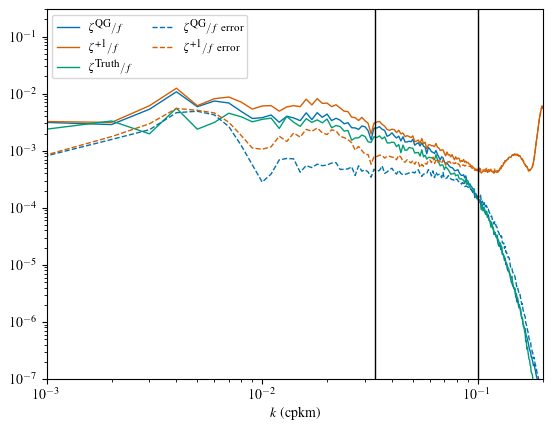

In [58]:
# Compute 2D Real FFT of the windowed truth vorticity
zeta_truth_windowed__ = rfft2(ds_lpfilter.zeta_windowed.values)

# Compute 2D Real FFT of the Geostrophic Balance vorticity
zeta_GeoBal__ = rfft2(ds_GeoBal.zeta_GeoBal.values)

# Re-transform SQG+1 vorticity:
# First invert the FFT normalization or process (irfft2) then take forward FFT (rfft2)
zeta_SQGp1 = irfft2(zeta_SQGp1__); zeta_SQGp1__ = rfft2(zeta_SQGp1)

# Calculate isotropic power spectra from the squared magnitude of the FFT coefficients
zeta_truth_spec = isospec_rfft( np.abs(zeta_truth_windowed__)**2 )
zeta_GeoBal_spec = isospec_rfft( np.abs(zeta_GeoBal__)**2 )
zeta_SQGp1_spec = isospec_rfft( np.abs(zeta_SQGp1__)**2 )

# Calculate the error power spectra (difference between estimate and truth)
err_SQGp1_spec = isospec_rfft( np.abs(zeta_SQGp1__-zeta_truth_windowed__)**2 )
err_GeoBal_spec = isospec_rfft( np.abs(zeta_GeoBal__-zeta_truth_windowed__)**2 )

# Plot the power spectra on a log-log scale
# Comparisons of Geostrophic Balance (QG), SQG+1, and Truth
plt.loglog(k_ndim/k_fac,zeta_GeoBal_spec,color=[0,0.4453125,0.6953125],label=r"$\zeta^\textrm{QG}/f$")
plt.loglog(k_ndim/k_fac,zeta_SQGp1_spec,color=[0.83203125,0.3671875,0.],label=r"$\zeta^\textrm{+1}/f$")
plt.loglog(k_ndim/k_fac,zeta_truth_spec,color=[0.,0.6171875,0.44921875],label=r"$\zeta^\textrm{Truth}/f$")

# Plot the error spectra with dashed lines
plt.loglog(k_ndim/k_fac,err_GeoBal_spec,'--',color=[0,0.4453125,0.6953125],label=r"$\zeta^\textrm{QG}/f$ error")
plt.loglog(k_ndim/k_fac,err_SQGp1_spec,'--',color=[0.83203125,0.3671875,0.],label=r"$\zeta^\textrm{+1}/f$ error")

# Add vertical reference lines for specific wavenumbers (e.g., 30 km, 10 km scales)
plt.axvline(1/30,color='k')
plt.axvline(1/10,color='k')
# plt.axvline(1/15,color='k')


plt.ylim([1e-7,0.3])
plt.xlabel("$k$ (cpkm)")
plt.legend(ncol=2)

0.060833799593343535
0.21167730200718732
-2.4796002127466843


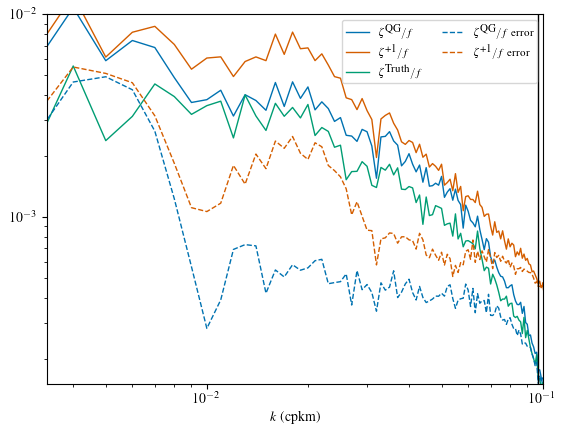

In [59]:
plt.loglog(k_ndim/k_fac,zeta_GeoBal_spec,color=[0,0.4453125,0.6953125],label=r"$\zeta^\textrm{QG}/f$")
plt.loglog(k_ndim/k_fac,zeta_SQGp1_spec,color=[0.83203125,0.3671875,0.],label=r"$\zeta^\textrm{+1}/f$")
plt.loglog(k_ndim/k_fac,zeta_truth_spec,color=[0.,0.6171875,0.44921875],label=r"$\zeta^\textrm{Truth}/f$")

plt.loglog(k_ndim/k_fac,err_GeoBal_spec,'--',color=[0,0.4453125,0.6953125],label=r"$\zeta^\textrm{QG}/f$ error")
plt.loglog(k_ndim/k_fac,err_SQGp1_spec,'--',color=[0.83203125,0.3671875,0.],label=r"$\zeta^\textrm{+1}/f$ error")

# plt.axvline(1/30,color='k')
# plt.axvline(1/10,color='k')
plt.axvline(k_ndim[97]/k_fac,color='k')

plt.xlim([1/300,1/10])
plt.ylim([1.5e-4,0.01])
plt.xlabel("$k$ (cpkm)")
plt.legend(ncol=2)

print(np.sum(err_GeoBal_spec))
print(np.sum(err_SQGp1_spec))
print(1-np.sum(err_SQGp1_spec)/np.sum(err_GeoBal_spec))

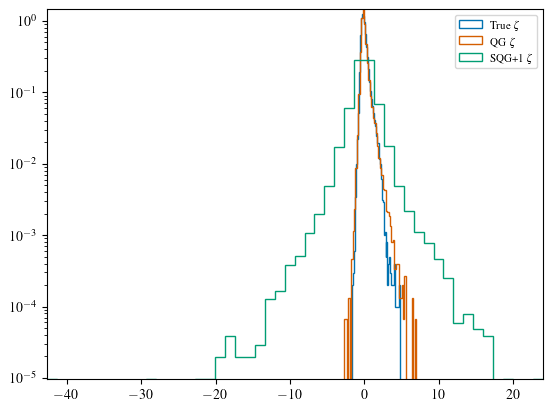

0.03157943450560305
0.7124692097605497


In [60]:
# zrel_lp = irfft2(zeta_rel_lp__)[xl:xh,yl:yh]

plt.hist(zeta_truth_crop.ravel(), log=True, density=True, bins=50, histtype='step',label="True $\zeta$")
plt.hist(zeta_GeoBal_crop.ravel(), log=True, density=True, bins=50, histtype='step',label="QG $\zeta$")
plt.hist(zeta_SQGp1_crop.ravel(), log=True, density=True, bins=50, histtype='step',label="SQG+1 $\zeta$")

plt.legend()
plt.show()

print(wasserstein_distance(zeta_truth_crop.ravel(),zeta_GeoBal_crop.ravel()))
print(wasserstein_distance(zeta_truth_crop.ravel(),zeta_SQGp1_crop.ravel()))

We have here 
$$ \Phi = \frac{1}{2}(\Phi^0_z)^2 - \Phi_z^0 \times \Phi^0_{zz}$$

In [28]:
def PHIp1__(phi0s__):
    phi0s_z = irfft2(phi0s__*Ka)
    term_1 = rfft2(1/2*phi0s_z**2)

    phi0s_zz = irfft2(phi0s__*Ka*Ka)
    term_2 = -rfft2(phi0s_z*phi0s_zz)/Kaa

    return term_1+term_2

Here 
$$ F_z = \Phi^0_y \cdot \Phi^0_{zz} + \Phi^0_{yz} \cdot \Phi^0_z - \Phi^0_z \cdot \Phi^0_y $$

This is the derivative of : 
$$  \widehat{F^1} = \frac{1}{\text{Bu}} \left( \widehat{\Phi_y^0\Phi_z^0} - \widehat{\Phi_y^{0,t}\Phi_z^{0,t}} e^{\mu z}\right) $$

In [29]:
def FZ_p1__(phi0s__):
    phi0s_y = irfft2((phi0s__.T*1j*ky).T)
    phi0s_zz = irfft2(phi0s__*Ka*Ka)
    phi0s_yz = irfft2((phi0s__.T*1j*ky*Ka.T).T)
    phi0s_z = irfft2(phi0s__*Ka)
    term_1 = rfft2(phi0s_y*phi0s_zz+phi0s_yz*phi0s_z)
    
    term_2 = -(rfft2(phi0s_z*phi0s_y).T*Ka.T).T

    return (term_1+term_2)

Here

$$ G_z = -\Phi^0_x \cdot \Phi^0_{zz} + \Phi^0_{xz} \cdot \Phi^0_z + \Phi^0_z \cdot \Phi^0_x $$

This is the derivative of 

$ \widehat{G^1} = -\frac{1}{\text{Bu}} \left( \widehat{\Phi_x^0 \Phi_z^0} - \widehat{\Phi_x^{0,t} \Phi_z^{0,t}} e^{\mu z} \right) $

In [30]:
def GZ_p1__(phi0s__):
    phi0s_x = irfft2(phi0s__*1j*kx)
    phi0s_zz = irfft2(phi0s__*Ka*Ka)
    phi0s_xz = irfft2(phi0s__*1j*kx*Ka)
    phi0s_z = irfft2(phi0s__*Ka)
    term_1 = -rfft2(phi0s_x*phi0s_zz+phi0s_xz*phi0s_z)
    
    term_2 = +(rfft2(phi0s_z*phi0s_x).T*Ka.T).T

    return (term_1+term_2)

This is $u$ corredpond to 

$$   \hat{u}^t = \hat{u}(z = 0)  \nonumber
    = -\Phi_y^{0,t} - \epsilon \cdot \frac{1}{\text{Bu}} \left[ \underbrace{\widehat{\Phi_y^{0,t}\Phi_{zz}^{0,t}} + 2\widehat{\Phi_{yz}^{0,t}\Phi_z^{0,t}}}_{\text{Interior Part}} {\color{red} - } \underbrace{\mu \widehat{\Phi_y^{0,t}\Phi_{zz}^{0,t}}  {\color{red} - }  \frac{il}{\mu}\widehat{\Phi_{z}^{0,t}\Phi_{zz}^{0,t}}}_{\text{Surface Part}}\right]$$

Now 

In [31]:
def U_0p1__(phi0s__):
    PHIy_0__ = (phi0s__.T*1j*ky).T
    
    PHIp1__eval = PHIp1__(phi0s__)
    PHIy_p1__ = (PHIp1__eval.T*1j*ky).T
    
    FZ_p1__eval = FZ_p1__(phi0s__)

    return -PHIy_0__+1*eps*(-PHIy_p1__-FZ_p1__eval)

In [32]:
def V_0p1__(phi0s__):
    PHIx_0__ = phi0s__*1j*kx
    
    PHIp1__eval = PHIp1__(phi0s__)
    PHIx_p1__ = PHIp1__eval*1j*kx
    
    GZ_p1__eval = GZ_p1__(phi0s__)

    return PHIx_0__+1*eps*(PHIx_p1__-GZ_p1__eval)

In [33]:
def strain_fuv(phi0s__):
    Ux_p1 = irfft2( U_0p1__(phi0s__)*1j*kx  *lowpass_filter**2)
    Vx_p1 = irfft2( V_0p1__(phi0s__)*1j*kx  *lowpass_filter**2)
    Uy_p1 = irfft2( (U_0p1__(phi0s__).T*1j*ky).T  *lowpass_filter**2)
    Vy_p1 = irfft2( (V_0p1__(phi0s__).T*1j*ky).T  *lowpass_filter**2)
    
    strain_fuvp1 = np.sqrt(  (Ux_p1-Vy_p1)**2+(Vx_p1+Uy_p1)**2  )
    
    strain_fuv__ = rfft2(strain_fuvp1)

    return strain_fuv__

In [34]:
#################
strain_fuv__ = strain_fuv(params__)
# strain_fuv__ = strain_fuv__

# sfuv_p1 = irfft2(strain_fuv__)[xl:xh,yl:yh]

0.694615
0.6616143417079428
0.21467177443830074


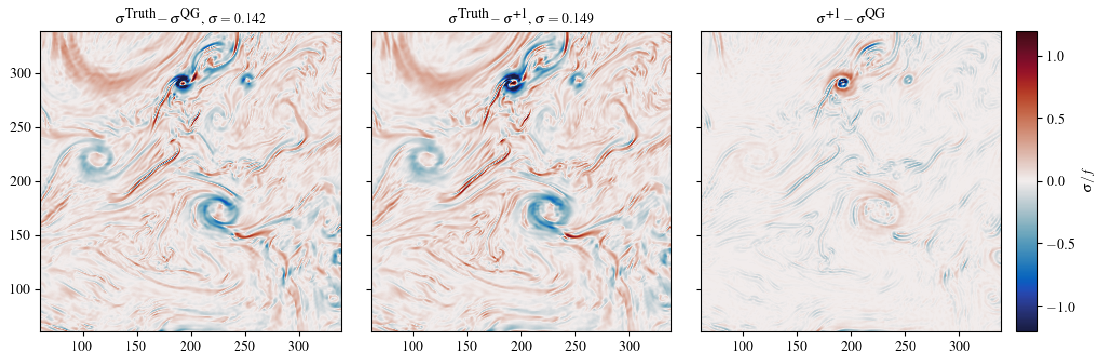

In [35]:
xl = ds_lpfilter.cut_id.values; xh = -ds_lpfilter.cut_id.values
yl = ds_lpfilter.cut_id.values; yh = -ds_lpfilter.cut_id.values

fig = plt.figure(figsize=(9*1.5, 2.6*1.5))

grid = ImageGrid(fig, 111,          # as in plt.subplot(111)
                 nrows_ncols=(1,3),
                 axes_pad=0.3,
                 share_all=True,
                 cbar_location="right",
                 cbar_mode="single",
                 cbar_size="7%",
                 cbar_pad=0.15,
                 )
cmax = 1.2

strain_truth_crop = ds_truth.strain_surface.values[xl:xh,yl:yh]
strain_GeoBal_crop = ds_GeoBal.strain_GeoBal.values[xl:xh,yl:yh]
strain_SQGp1_crop = irfft2(strain_fuv__)[xl:xh,yl:yh]

im0 = grid[0].pcolor(x[xl:xh,yl:yh]/1000,y[xl:xh,yl:yh]/1000,strain_truth_crop-strain_GeoBal_crop, cmap=cmo.balance, vmin=-cmax, vmax=cmax)
grid[0].set_title(r"$\sigma^\textrm{Truth}-\sigma^\textrm{QG}$, $\sigma=%.3f$" %np.std(strain_truth_crop-strain_GeoBal_crop))
im1 = grid[1].pcolor(x[xl:xh,yl:yh]/1000,y[xl:xh,yl:yh]/1000,strain_truth_crop-strain_SQGp1_crop, cmap=cmo.balance, vmin=-cmax, vmax=cmax)
grid[1].set_title(r"$\sigma^\textrm{Truth}-\sigma^\textrm{+1}$, $\sigma=%.3f$" %np.std(strain_truth_crop-strain_SQGp1_crop))
im2 = grid[2].pcolor(x[xl:xh,yl:yh]/1000,y[xl:xh,yl:yh]/1000,(strain_SQGp1_crop-strain_GeoBal_crop), cmap=cmo.balance, vmin=-cmax, vmax=cmax)
grid[2].set_title(r"$\sigma^\textrm{+1}-\sigma^\textrm{QG}$")

cbar = grid[2].cax.colorbar(im2)
cbar.set_label("$\sigma/f$")

print(rel_err(strain_truth_crop,strain_SQGp1_crop))
print(rel_err(strain_truth_crop,strain_GeoBal_crop))
print(np.std(strain_truth_crop))


Text(0.5, 1.0, 'Truth')

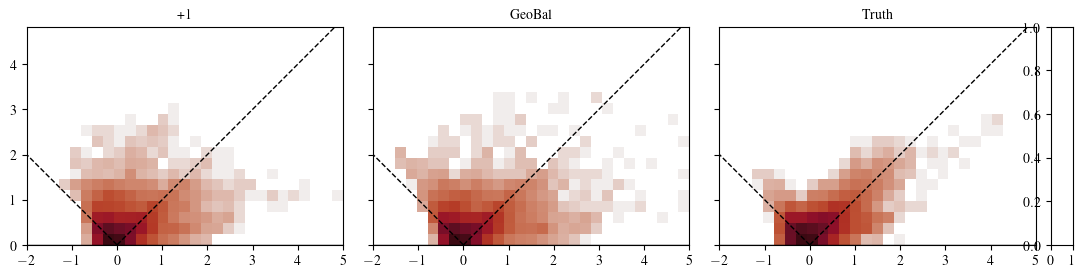

In [36]:
zetat_all = zeta_SQGp1_crop
straint_all = strain_SQGp1_crop

zmax = 5
zmin = -2

z_range = np.linspace(zmin,zmax,30)
s_range = np.arange(0,zmax,z_range[-1]-z_range[-2])
axs_max = zmax

######################################
fig = plt.figure(figsize=(9*1.5, 2.6*1.5))

grid = ImageGrid(fig, 111,          # as in plt.subplot(111)
                 nrows_ncols=(1,3),
                 axes_pad=0.3,
                 share_all=True,
                 cbar_location="right",
                 cbar_mode="single",
                 cbar_size="7%",
                 cbar_pad=0.15,
                 )

im0 = grid[0].hist2d(zetat_all.ravel(),straint_all.ravel(), density=True, bins=[z_range, s_range], cmap=cmo.amp, norm=colors.LogNorm())
grid[0].plot([0,axs_max],[0,axs_max],'--',color='k'); grid[0].plot([0,-axs_max],[0,axs_max],'--',color='k'); grid[0].axhline(0,color='k')
grid[0].set_title("+1")
# plt.axis('equal'); 
# plt.xlim(min(zetat_all.ravel()),max(zetat_all.ravel()))
# plt.ylim(0,max(zetat_all.ravel()))
# plt.colorbar()
# plt.title('Vorticity-Strain JPDF')
# plt.xlabel("Vorticity ($\zeta^t/f$)")
# plt.ylabel("Strain ($\sigma^t/f$)")

######################
zetat_all = zeta_GeoBal_crop
straint_all = strain_GeoBal_crop

im1 = grid[1].hist2d(zetat_all.ravel(),straint_all.ravel(), density=True, bins=[z_range, s_range], cmap=cmo.amp, norm=colors.LogNorm())
grid[1].plot([0,axs_max],[0,axs_max],'--',color='k'); grid[1].plot([0,-axs_max],[0,axs_max],'--',color='k'); grid[1].axhline(0,color='k')
grid[1].set_title("GeoBal")

######################
zetat_all = zeta_truth_crop
straint_all = strain_truth_crop

im2 = grid[2].hist2d(zetat_all.ravel(),straint_all.ravel(), density=True, bins=[z_range, s_range], cmap=cmo.amp, norm=colors.LogNorm())
grid[2].plot([0,axs_max],[0,axs_max],'--',color='k'); grid[2].plot([0,-axs_max],[0,axs_max],'--',color='k'); grid[2].axhline(0,color='k')
grid[2].set_title("Truth")

# grid[2].cax.colorbar()
# cbar.set_label("$\zeta/f$")

# plt.show()